In [1]:
# from google.colab import drive

# drive.mount('/content/drive')

# %cd /content/drive/MyDrive/faster_rcnn
# %cp VOC2007.zip /content
# %cp VOC2012.zip /content

Mounted at /content/drive
/content/drive/MyDrive/faster_rcnn
/content


In [2]:
from pathlib import Path
import zipfile

data_path = Path("data/")
data_path.mkdir(exist_ok=True)

voc2007_zip_path = Path("VOC2007.zip")
voc2012_zip_path = Path("VOC2012.zip")

if not voc2007_zip_path.exists() or not voc2012_zip_path.exists():
    raise RuntimeError("Dataset not found.")

print("Extracting 2007 dataset ...")

with zipfile.ZipFile(voc2007_zip_path, "r") as zip_ref:
    zip_ref.extractall(data_path)

print(f"Extracting 2012 dataset ...")
with zipfile.ZipFile(voc2012_zip_path, "r") as zip_ref:
    zip_ref.extractall(data_path)

Extracting 2007 dataset ...
Extracting 2012 dataset ...


In [1]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
from src.backbone import Backbone
from src.rpn import RPN_Head, RegionProposalNetwork

backbone = Backbone().to(device)
rpn_head = RPN_Head(in_channels=1024, mid_channels=512).to(device)


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 168MB/s] 


In [ ]:
from pathlib import Path
import torch

# checkpoint_dir = Path("/content/drive/MyDrive/faster_rcnn/checkpoints")
checkpoint_dir = Path("rpn_checkpoints")

existing_checkpoints = sorted(checkpoint_dir.glob("step1_epoch_*.pt"),
                              key = lambda p : int(p.stem.split("_epoch_")[1]))

print(f"Existing checkpoints: {existing_checkpoints}")

if existing_checkpoints:
    latest_checkpoint = existing_checkpoints[-1]
    print(f"Loading checkpoint: {latest_checkpoint}")

    checkpoint = torch.load(latest_checkpoint, map_location=device)
    
    backbone.load_state_dict(checkpoint['backbone_state_dict'])
    rpn_head.load_state_dict(checkpoint['rpn_head_state_dict'])



Existing checkpoints: [PosixPath('checkpoints/step1_epoch_1.pt'), PosixPath('checkpoints/step1_epoch_2.pt'), PosixPath('checkpoints/step1_epoch_3.pt'), PosixPath('checkpoints/step1_epoch_4.pt'), PosixPath('checkpoints/step1_epoch_5.pt'), PosixPath('checkpoints/step1_epoch_6.pt'), PosixPath('checkpoints/step1_epoch_7.pt'), PosixPath('checkpoints/step1_epoch_8.pt'), PosixPath('checkpoints/step1_epoch_9.pt'), PosixPath('checkpoints/step1_epoch_10.pt'), PosixPath('checkpoints/step1_epoch_11.pt'), PosixPath('checkpoints/step1_epoch_12.pt'), PosixPath('checkpoints/step1_epoch_13.pt')]
Loading checkpoint: checkpoints/step1_epoch_13.pt


In [14]:
from src.backbone import backbone_transform
from src.dataset import get_voc_img_paths_train, get_voc_img_paths_test, create_voc_dataloader

transform = backbone_transform

voc2007_img_paths_train, voc2012_img_paths_train = get_voc_img_paths_train()
voc2007_img_paths_test, voc2012_img_paths_test = get_voc_img_paths_test()

combined_train_img_paths = voc2007_img_paths_train + voc2012_img_paths_train

train_dataloader = create_voc_dataloader(img_paths_list=combined_train_img_paths, transform=transform, batch_size=2, shuffle=True)

test_dataloader = create_voc_dataloader(img_paths_list=voc2007_img_paths_test, transform=transform, batch_size=2, shuffle=True)

In [15]:
def compute_iou_matrix(boxes_a, boxes_b):
        # Compute the IoU matrix between two sets of boxes.
        # boxes_a: [num_a, 4], boxes_b: [num_b, 4] -- BOTH in CORNER format (x1, y1, x2, y2).
        # Returns: IoU matrix of shape [num_a, num_b]
        # (Eval-time proposals and GT are both corner format, so no conversion needed here.
        #  This is separate from src/rpn.py's compute_iou_matrix, which takes center-format anchors.)

        a_x1, a_y1, a_x2, a_y2 = boxes_a[:, 0], boxes_a[:, 1], boxes_a[:, 2], boxes_a[:, 3]
        b_x1, b_y1, b_x2, b_y2 = boxes_b[:, 0], boxes_b[:, 1], boxes_b[:, 2], boxes_b[:, 3]

        # Calculate intersection (unsqueeze to align dimensions for broadcasting)
        inter_x1 = torch.max(a_x1.unsqueeze(1), b_x1.unsqueeze(0))
        inter_y1 = torch.max(a_y1.unsqueeze(1), b_y1.unsqueeze(0))
        inter_x2 = torch.min(a_x2.unsqueeze(1), b_x2.unsqueeze(0))
        inter_y2 = torch.min(a_y2.unsqueeze(1), b_y2.unsqueeze(0))

        inter_area = torch.clamp(inter_x2 - inter_x1, min=0) * torch.clamp(inter_y2 - inter_y1, min=0)

        # Calculate union
        area_a = (a_x2 - a_x1) * (a_y2 - a_y1)
        area_b = (b_x2 - b_x1) * (b_y2 - b_y1)
        union_area = area_a.unsqueeze(dim=1) + area_b.unsqueeze(dim=0) - inter_area

        iou_matrix = inter_area / union_area
        return iou_matrix

def compute_recall_at_iou(proposals, gt_boxes):
    if gt_boxes.shape[0] == 0:
        return 0, 0  # no GT boxes in this image, nothing to recall

    if proposals.shape[0] == 0:
        return [0, 0, gt_boxes.shape[0]], gt_boxes.shape[0]  # no proposals -> all GT missed

    # proposals and gt_boxes are both CORNER format (x1, y1, x2, y2) at eval time.
    iou_matrix = compute_iou_matrix(proposals, gt_boxes)
    max_iou_per_gt, _ = iou_matrix.max(dim=0)
    num_recalled = [
        (max_iou_per_gt >= 0.5).sum().item(),
        ((0.3 <= max_iou_per_gt) & (max_iou_per_gt < 0.5)).sum().item(),
        (max_iou_per_gt < 0.3).sum().item(),
    ]
    return num_recalled, gt_boxes.shape[0]

In [18]:
sum_num_recalled_3 = 0
sum_num_recalled_5 = 0
sum_num_recalled_3_5 = 0
sum_num_gt_boxes = 0

for i in range(100):
    batch_imgs, batch_boxes, batch_labels, img_sizes_before_pad = next(iter(test_dataloader))

    rpn_network = RegionProposalNetwork(rpn_head=rpn_head).to(device)

    with torch.inference_mode():
        backbone.eval()
        rpn_head.eval()
        rpn_network.eval()

        batch_feature_maps = backbone(batch_imgs.to(device))
        # print(f"batch_feature_maps.shape: {batch_feature_maps.shape}")
        batch_scores, batch_proposals = rpn_network(batch_feature_maps, batch_imgs.shape[2], batch_imgs.shape[3], img_sizes_before_pad)

        batch_boxes = [batch_boxes[i].to(device) for i in range(len(batch_boxes))]

        num_recalled, num_gt_boxes = compute_recall_at_iou(batch_proposals[0], batch_boxes[0])

        sum_num_recalled_3 += num_recalled[2]
        sum_num_recalled_5 += num_recalled[0]
        sum_num_recalled_3_5 += num_recalled[1]
        sum_num_gt_boxes += num_gt_boxes

print(f"Total GT boxes: {sum_num_gt_boxes}, Total recalled (IoU >= 0.5): {sum_num_recalled_5}, Recall: {sum_num_recalled_5 / sum_num_gt_boxes if sum_num_gt_boxes > 0 else 0:.4f}")
print(f"Total GT boxes: {sum_num_gt_boxes}, Total recalled (0.3 <= IoU <= 0.5): {sum_num_recalled_3_5}, Recall: {sum_num_recalled_3_5 / sum_num_gt_boxes if sum_num_gt_boxes > 0 else 0:.4f}")
print(f"Total GT boxes: {sum_num_gt_boxes}, Total recalled (IoU < 0.3): {sum_num_recalled_3}, Recall: {sum_num_recalled_3 / sum_num_gt_boxes if sum_num_gt_boxes > 0 else 0:.4f}")


Total GT boxes: 267, Total recalled (IoU >= 0.5): 220, Recall: 0.8240
Total GT boxes: 267, Total recalled (0.3 <= IoU <= 0.5): 22, Recall: 0.0824
Total GT boxes: 267, Total recalled (IoU < 0.3): 25, Recall: 0.0936


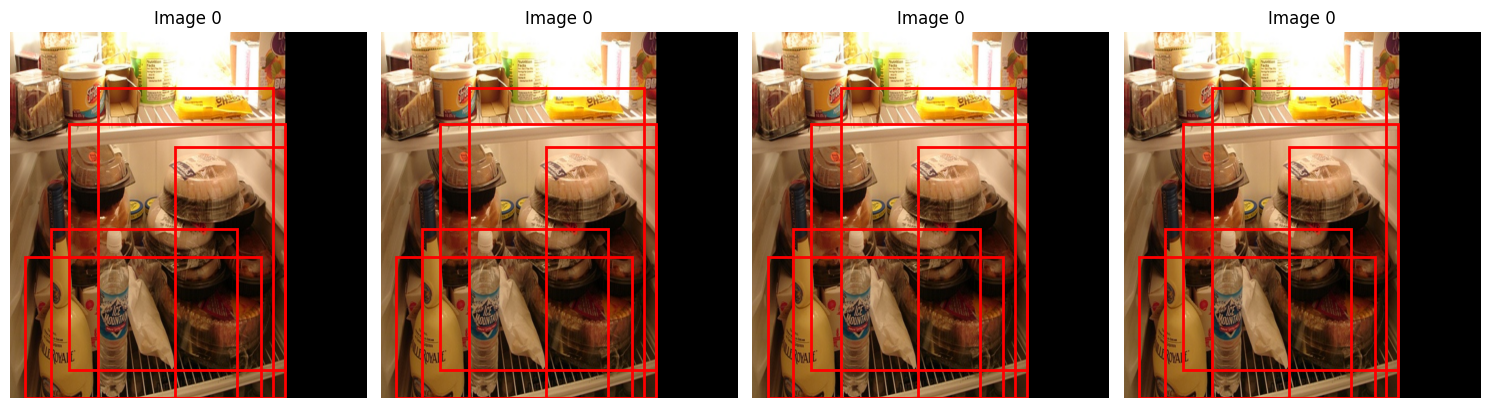

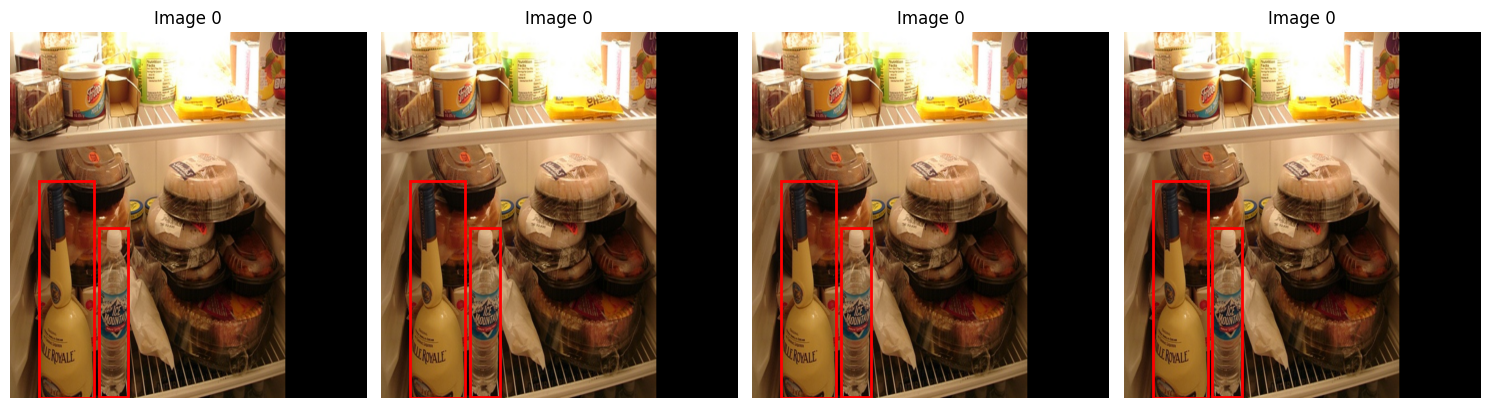

In [20]:
from src.utils import display_random_batch_images

scores, decoded_boxes = batch_scores[0], batch_proposals[0]

top_scores, top_indices = torch.topk(scores, k=5)
top_decoded_boxes = decoded_boxes[top_indices]

display_random_batch_images([batch_imgs[0]], [top_decoded_boxes])
display_random_batch_images([batch_imgs[0]], [batch_boxes[0]])
